In [2]:
import pandas as pd
import numpy as np

In [3]:
df = pd.read_csv("rolling_stones_spotify.csv")
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1610 entries, 0 to 1609
Data columns (total 18 columns):
 #   Column            Non-Null Count  Dtype  
---  ------            --------------  -----  
 0   Unnamed: 0        1610 non-null   int64  
 1   name              1610 non-null   object 
 2   album             1610 non-null   object 
 3   release_date      1610 non-null   object 
 4   track_number      1610 non-null   int64  
 5   id                1610 non-null   object 
 6   uri               1610 non-null   object 
 7   acousticness      1610 non-null   float64
 8   danceability      1610 non-null   float64
 9   energy            1610 non-null   float64
 10  instrumentalness  1610 non-null   float64
 11  liveness          1610 non-null   float64
 12  loudness          1610 non-null   float64
 13  speechiness       1610 non-null   float64
 14  tempo             1610 non-null   float64
 15  valence           1610 non-null   float64
 16  popularity        1610 non-null   int64  


In [4]:
df.describe()

,Unnamed: 0,track_number,acousticness,danceability,energy,instrumentalness,liveness,loudness,speechiness,tempo,valence,popularity,duration_ms
count,1610.000000,1610.000000,1610.000000,1610.000000,1610.000000,1610.000000,1610.00000,1610.000000,1610.000000,1610.000000,1610.000000,1610.000000,1610.000000
mean,804.500000,8.613665,0.250475,0.468860,0.792352,0.164170,0.49173,-6.971615,0.069512,126.082033,0.582165,20.788199,257736.488199
std,464.911282,6.560220,0.227397,0.141775,0.179886,0.276249,0.34910,2.994003,0.051631,29.233483,0.231253,12.426859,108333.474920
min,0.000000,1.000000,0.000009,0.104000,0.141000,0.000000,0.02190,-24.408000,0.023200,46.525000,0.000000,0.000000,21000.000000
25%,402.250000,4.000000,0.058350,0.362250,0.674000,0.000219,0.15300,-8.982500,0.036500,107.390750,0.404250,13.000000,190613.000000
50%,804.500000,7.000000,0.183000,0.458000,0.848500,0.013750,0.37950,-6.523000,0.051200,124.404500,0.583000,20.000000,243093.000000
75%,1206.750000,11.000000,0.403750,0.578000,0.945000,0.179000,0.89375,-4.608750,0.086600,142.355750,0.778000,27.000000,295319.750000
max,1609.000000,47.000000,0.994000,0.887000,0.999000,0.996000,0.99800,-1.014000,0.624000,216.304000,0.974000,80.000000,981866.000000


In [5]:
df.isnull().sum()

Unnamed: 0          0
name                0
album               0
release_date        0
track_number        0
id                  0
uri                 0
acousticness        0
danceability        0
energy              0
instrumentalness    0
liveness            0
loudness            0
speechiness         0
tempo               0
valence             0
popularity          0
duration_ms         0
dtype: int64

In [6]:
df.duplicated().sum()

0

In [7]:
# checking datatype of release_date feature
df['release_date']

0       2022-06-10
1       2022-06-10
2       2022-06-10
3       2022-06-10
4       2022-06-10
           ...    
1605    1964-04-16
1606    1964-04-16
1607    1964-04-16
1608    1964-04-16
1609    1964-04-16
Name: release_date, Length: 1610, dtype: object

In [8]:
# Changing datatype to datetime and adding an year feature
df['release_date'] = pd.to_datetime(df['release_date'])
df['year'] = df['release_date'].dt.year

print(df['release_date'], "\n",df['year'])

0      2022-06-10
1      2022-06-10
2      2022-06-10
3      2022-06-10
4      2022-06-10
          ...    
1605   1964-04-16
1606   1964-04-16
1607   1964-04-16
1608   1964-04-16
1609   1964-04-16
Name: release_date, Length: 1610, dtype: datetime64[ns] 
 0       2022
1       2022
2       2022
3       2022
4       2022
        ... 
1605    1964
1606    1964
1607    1964
1608    1964
1609    1964
Name: year, Length: 1610, dtype: int32


In [9]:
# Dropping irrelevant features

df = df.drop(['id','name','uri'], axis=1)
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1610 entries, 0 to 1609
Data columns (total 16 columns):
 #   Column            Non-Null Count  Dtype         
---  ------            --------------  -----         
 0   Unnamed: 0        1610 non-null   int64         
 1   album             1610 non-null   object        
 2   release_date      1610 non-null   datetime64[ns]
 3   track_number      1610 non-null   int64         
 4   acousticness      1610 non-null   float64       
 5   danceability      1610 non-null   float64       
 6   energy            1610 non-null   float64       
 7   instrumentalness  1610 non-null   float64       
 8   liveness          1610 non-null   float64       
 9   loudness          1610 non-null   float64       
 10  speechiness       1610 non-null   float64       
 11  tempo             1610 non-null   float64       
 12  valence           1610 non-null   float64       
 13  popularity        1610 non-null   int64         
 14  duration_ms       1610 n

In [10]:
df['popularity'].value_counts()

popularity
20    81
17    71
16    69
19    69
18    65
      ..
71     1
54     1
59     1
61     1
64     1
Name: count, Length: 69, dtype: int64

In [11]:
popular_songs = df[df['popularity'] > 70]
album_counts = popular_songs['album'].value_counts()
album_counts.head(10) 

album
Tattoo You (2009 Re-Mastered)                 1
Some Girls                                    1
Goats Head Soup (Remastered 2009)             1
Let It Bleed                                  1
Beggars Banquet (50th Anniversary Edition)    1
Aftermath                                     1
Out Of Our Heads                              1
Name: count, dtype: int64

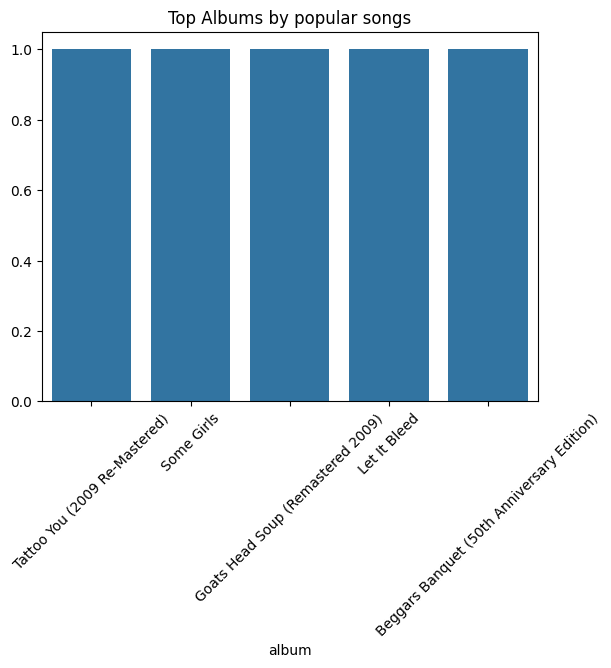

In [ ]:
# Visualization
import seaborn as sns
import matplotlib.pyplot as plt

sns.barplot(x=album_counts.index[:5], y=album_counts.values[:5])
plt.xticks(rotation=45)
plt.title("Top Albums by popular songs")
plt.show()

array([[<Axes: title={'center': 'Unnamed: 0'}>,
        <Axes: title={'center': 'release_date'}>,
        <Axes: title={'center': 'track_number'}>,
        <Axes: title={'center': 'acousticness'}>],
       [<Axes: title={'center': 'danceability'}>,
        <Axes: title={'center': 'energy'}>,
        <Axes: title={'center': 'instrumentalness'}>,
        <Axes: title={'center': 'liveness'}>],
       [<Axes: title={'center': 'loudness'}>,
        <Axes: title={'center': 'speechiness'}>,
        <Axes: title={'center': 'tempo'}>,
        <Axes: title={'center': 'valence'}>],
       [<Axes: title={'center': 'popularity'}>,
        <Axes: title={'center': 'duration_ms'}>,
        <Axes: title={'center': 'year'}>, <Axes: >]], dtype=object)

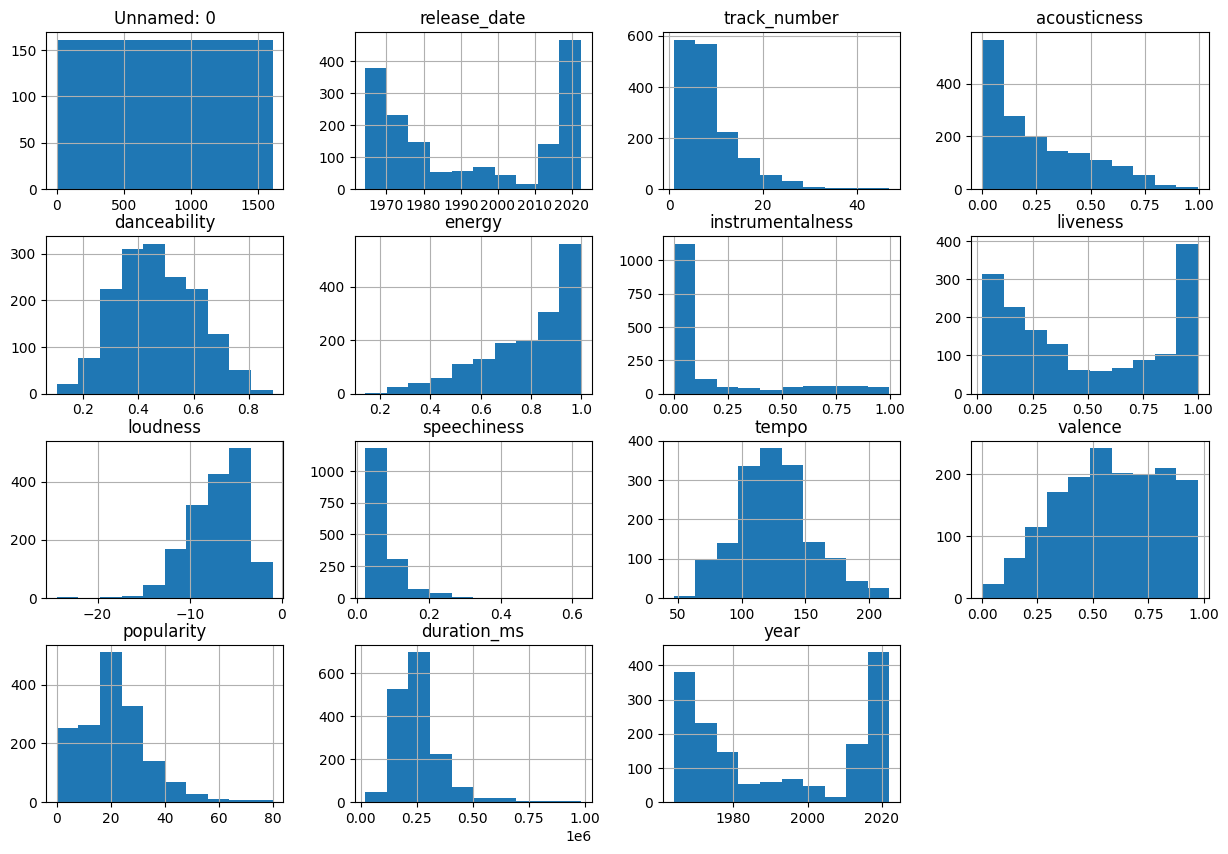

In [ ]:
# Distribution plots
df.hist(figsize=(15,10))

In [18]:
sns.heatmap(df.corr(), annot=True, cmap="coolwarm")

ValueError: could not convert string to float: 'Licked Live In NYC'